In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
from src.data_loader import VesselDataLoader
from src.data_processing import DataProcessor
from src.regime_classifier import BayesianHMMClassifier

c:\Users\ext-adam\Desktop\INTERNSHIP\Mariner\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Path to your raw telemetry
raw_data_file1 = root_path / "data" / "raw" / "Rotherhithe_voy_179.csv"
raw_data_file2 = root_path / "data" / "raw" / "Wembley_voy_236.csv"

# Instantiate
loader1 = VesselDataLoader(raw_data_file1)
loader2 = VesselDataLoader(raw_data_file2)

# Load and clean the data
raw_df1 = loader1.load_and_clean()
raw_df2 = loader2.load_and_clean()

# Apply the Aggressive Butterworth strategy
processor1 = DataProcessor(raw_df1)
processed_df1 = processor1.extract_features_and_filter(
    filter_method='butter', 
    cutoff=0.05, 
    order=2
)

processor2 = DataProcessor(raw_df2)
processed_df2 = processor2.extract_features_and_filter(
    filter_method='butter',
    cutoff=0.05,
    order=2
)

In [4]:
# Isolate our pruned 6-feature orthogonal matrix
continuous_features = [
    'AE_POWER(kW)', 'ENERGY_INTENSITY', 
    'MANEUVER_INTENSITY', 'POWER_TV_ENERGY', 'PF_DERIVATIVE'
]
discrete_features = ['NUM_GENERATORS']

X_cont = processed_df1[continuous_features].values
X_disc = processed_df1[discrete_features].values.flatten()

# 2. Define the Experimental Matrix
experiments = [
    {"name": "SVI_ELA_K8_W10", "K": 8, "inertia": 10.0, "method": "svi"},
    {"name": "SVI_ELA_K8_W40", "K": 8, "inertia": 40.0, "method": "svi"},
    {"name": "SVI_ELA_K8_W160", "K": 8, "inertia": 160.0, "method": "svi"},
    {"name": "SVI_ELA_K8_W640", "K": 8, "inertia": 640.0, "method": "svi"},

]

results_archive = []

print(f"Dataset ready. T={len(processed_df1)} timesteps (approx {len(processed_df1)*5/60:.1f} hours).")

Dataset ready. T=2879 timesteps (approx 239.9 hours).


In [5]:
results_archive = []

for exp in experiments:
    print(f"\n>>> Launching Experiment: {exp['name']} (K={exp['K']}, Method={exp.get('method', 'svi')})")
    
    hmm = BayesianHMMClassifier(n_components=exp['K'], inertia_weight=exp['inertia'])
    
    # --- LOGIC SWITCH ---
    if exp.get('method') == 'hmc':
        # Rigorous sampling
        hmm.fit(X_cont, X_disc, method='hmc', num_warmup=300, num_samples=500)
        final_metric = "N/A (Sampling)" 
    else:
        # Fast optimization
        hmm.fit(X_cont, X_disc, method='svi', num_steps=5000)
        final_metric = round(hmm.svi_result.losses[-1], 2)
    
    # Decode sequence
    state_sequence = hmm.predict(X_cont, X_disc)
    
    # Physical Diagnostics
    transitions = np.sum(state_sequence[1:] != state_sequence[:-1])
    mean_dwell_hrs = (len(X_cont) / max(transitions, 1)) * (5 / 60)
    
    unique_states, counts = np.unique(state_sequence, return_counts=True)
    active_k = len(unique_states)
    state_dist = {f"State_{k}": f"{(c/len(state_sequence))*100:.1f}%" for k, c in zip(unique_states, counts)}
    
    results_archive.append({
        "Experiment": exp['name'],
        "Method": exp.get('method', 'svi'),
        "K_Active": active_k,
        "Transitions": transitions,
        "Mean Dwell (hrs)": round(mean_dwell_hrs, 2),
        "Metric": final_metric,
        "Distribution": state_dist
    })

# Render the comparison
print("\n# MARINER HMM Inference Comparison")
print(pd.DataFrame(results_archive).drop(columns=['Distribution']).to_markdown(index=False))


>>> Launching Experiment: SVI_ELA_K8_W10 (K=8, Method=svi)
Warm-starting SVI means with KMeans (K=8)...
Running SVI...


100%|██████████| 5000/5000 [00:31<00:00, 157.41it/s, init loss: 26802.6309, avg. loss [4751-5000]: 3653.1985] 



>>> Launching Experiment: SVI_ELA_K8_W40 (K=8, Method=svi)
Warm-starting SVI means with KMeans (K=8)...
Running SVI...


100%|██████████| 5000/5000 [00:32<00:00, 151.54it/s, init loss: 27263.6211, avg. loss [4751-5000]: 3589.0032]  



>>> Launching Experiment: SVI_ELA_K8_W160 (K=8, Method=svi)
Warm-starting SVI means with KMeans (K=8)...
Running SVI...


100%|██████████| 5000/5000 [00:44<00:00, 111.75it/s, init loss: 29292.4570, avg. loss [4751-5000]: 5075.3794] 



>>> Launching Experiment: SVI_ELA_K8_W640 (K=8, Method=svi)
Warm-starting SVI means with KMeans (K=8)...
Running SVI...


100%|██████████| 5000/5000 [00:31<00:00, 157.98it/s, init loss: 37626.1328, avg. loss [4751-5000]: 3492.4512] 



# MARINER HMM Inference Comparison
| Experiment      | Method   |   K_Active |   Transitions |   Mean Dwell (hrs) |   Metric |
|:----------------|:---------|-----------:|--------------:|-------------------:|---------:|
| SVI_ELA_K8_W10  | svi      |          4 |            69 |               3.48 |  3646.46 |
| SVI_ELA_K8_W40  | svi      |          4 |            69 |               3.48 |  3585.61 |
| SVI_ELA_K8_W160 | svi      |          4 |            31 |               7.74 |  5062.12 |
| SVI_ELA_K8_W640 | svi      |          4 |            45 |               5.33 |  3488.42 |




# MARINER Bayesian HMM Topology Report

*(Evaluating thermodynamic and mechanical inertia constraints for WP9 profile extraction)*

| Experiment      | Method   |   K_Active |   Transitions |   Mean Dwell (hrs) |   Metric |
|:----------------|:---------|-----------:|--------------:|-------------------:|---------:|
| SVI_ELA_K8_W10  | svi      |          4 |            69 |               3.48 |  3646.46 |
| SVI_ELA_K8_W40  | svi      |          4 |            69 |               3.48 |  3585.61 |
| SVI_ELA_K8_W160 | svi      |          4 |            31 |               7.74 |  5062.12 |
| SVI_ELA_K8_W640 | svi      |          4 |            45 |               5.33 |  3488.42 |

## State Probability Mass Distribution
- **SVI_ELA_K8_W10**: {'State_0': '11.7%', 'State_1': '77.3%', 'State_5': '0.0%', 'State_7': '10.9%'}
- **SVI_ELA_K8_W40**: {'State_0': '11.7%', 'State_1': '77.3%', 'State_5': '0.0%', 'State_7': '10.9%'}
- **SVI_ELA_K8_W160**: {'State_0': '21.4%', 'State_1': '77.6%', 'State

KeyError: 'STATE_SVI_ELA_K8_W40'

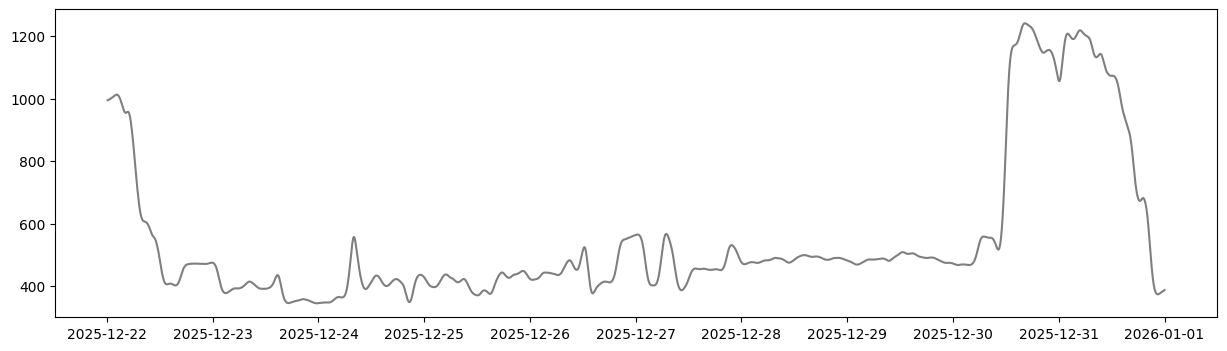

In [6]:
results_df = pd.DataFrame(results_archive)

print("\n\n# MARINER Bayesian HMM Topology Report\n")
print("*(Evaluating thermodynamic and mechanical inertia constraints for WP9 profile extraction)*\n")
print(results_df.drop(columns=['Distribution']).to_markdown(index=False))

print("\n## State Probability Mass Distribution")
for res in results_archive:
    print(f"- **{res['Experiment']}**: {res['Distribution']}")

# 5. Visualizing the Sequence (Optional but recommended)
# Pick the best performing model and plot the state timeline over AE_POWER
best_model_name = "SVI_ELA_K8_W40" # Change based on your analysis
plt.figure(figsize=(15, 4))
plt.plot(processed_df1.index, processed_df1['AE_POWER(kW)'], label="AE Power", color="black", alpha=0.5)
sc = plt.scatter(processed_df1.index, processed_df1['AE_POWER(kW)'], c=processed_df1[f"STATE_{best_model_name}"], cmap='Set1', s=10)
plt.colorbar(sc, label="Latent State")
plt.title(f"HMM Viterbi Decoding: {best_model_name}")
plt.ylabel("Power (kW)")
plt.xlabel("Time")
plt.tight_layout()
plt.show()